### Buid A basic chat bot with langraph (Graph API)

In [1]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages #recducer


In [2]:
class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    
    messages: Annotated[list, add_messages]

graph_builder =StateGraph(State)

In [3]:
graph_builder

In [4]:
import os 
from dotenv import load_dotenv
load_dotenv()
#os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")


True

In [5]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm = ChatGroq(model="openai/gpt-oss-20b")

In [6]:
# we also do like _>
# llm = init_chat_model("groq:llama-3.1-8b-instant")

In [7]:
# Node functionality 
def chatbot(state):
    return {"messages":[llm.invoke(state["messages"])]}


In [8]:
graph_builder = StateGraph(State)

## Adding node
graph_builder.add_node("llmchatbot",chatbot)

## Adding edges
graph_builder.add_edge(START,"llmchatbot")
graph_builder.add_edge("llmchatbot",END)

## compile the graph
graph = graph_builder.compile()

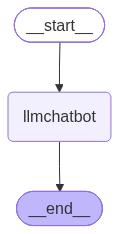

In [9]:
## visulization
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass


In [10]:
responce=graph.invoke({"messages":"Hi how are you"})

In [11]:
responce["messages"][-1]

AIMessage(content='Hello! I’m doing great—thanks for asking. How can I help you today?', additional_kwargs={'reasoning_content': 'User greeting. Just respond politely.'}, response_metadata={'token_usage': {'completion_tokens': 35, 'prompt_tokens': 75, 'total_tokens': 110, 'completion_time': 0.040006558, 'completion_tokens_details': {'reasoning_tokens': 8}, 'prompt_time': 0.004768399, 'prompt_tokens_details': None, 'queue_time': 0.316800308, 'total_time': 0.044774957}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_8d13edce1d', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0a680-ac19-76a2-a877-408b230dcfe3-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 75, 'output_tokens': 35, 'total_tokens': 110, 'output_token_details': {'reasoning': 8}})

In [12]:
for event in graph.stream({"messages":"hi how are you"}):
    for value in event.values():
        print(value["messages"][-1].content)


Hi there! I’m doing great—thanks for asking. How can I help you today?


### chat with Tools


In [13]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results=2)
tool.invoke("what is langgraph")

{'query': 'what is langgraph',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.ibm.com/think/topics/langgraph',
   'title': 'What is LangGraph?',
   'content': 'LangGraph, created by LangChain, is an open source AI agent framework designed to build, deploy and manage complex generative AI agent workflows. It provides a set of tools and libraries that enable users to create, run and optimize large language models (LLMs) in a scalable and efficient manner. At its core, LangGraph uses the power of graph-based architectures to model and manage the intricate relationships between various components of an AI agent workflow. [...] Agent systems: LangGraph provides a framework for building agent-based systems, which can be used in applications such as robotics, autonomous vehicles or video games.\n\nLLM applications: By using LangGraph’s capabilities, developers can build more sophisticated AI models that learn and improve over time. Norwegian Cr

In [14]:
## custom function 
def multply(a:int,b:int)->int:
    """MUTILPY a and  b 
    Args:
    a (int) : first int
    b (int) : second int
        int: output int 
    """
    return a*b


In [15]:
tools = [tool,multply]

In [16]:
llm_with_tool= llm.bind_tools(tools)

In [17]:
llm_with_tool

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.1', 'langchain': '1.3.18'}}, profile={'name': 'GPT OSS 20B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000002BCDEBAA660>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000002BCDEBAB0E0>, model_name='openai/gpt-oss-20b', model_kwargs={}, groq_api_key=SecretStr('**********')), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and

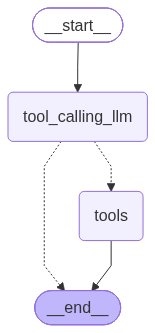

In [18]:
### let's create  state graph 
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node defination
def tool_calling_llm(state):
    return {"messages": [llm_with_tool.invoke(state["messages"])]}
# graph 
builder = StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## add edges
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools",END)
## complie the graph
graph=builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [19]:
responce=graph.invoke({"messages":"Hi how are you"})

In [20]:
responce["messages"][-1].content

"Hello! I'm doing well—thanks for asking. How can I help you today?"

In [21]:
for event in graph.stream({"messages":"hi how are you"}):
    for value in event.values():
        print(value["messages"][-1].content )

Hello! I’m doing great—thanks for asking. How can I help you today?


In [22]:
for m in responce["messages"]:
    m.pretty_print()

================================ Human Message =================================

Hi how are you
================================== Ai Message ==================================

Hello! I'm doing well—thanks for asking. How can I help you today?


In [23]:
responce = graph.invoke({"messages":"what is 2 multiplied by 7"})
for m in responce["messages"]:
    m.pretty_print()


================================ Human Message =================================

what is 2 multiplied by 7
================================== Ai Message ==================================
Tool Calls:
  multply (fc_db9b776d-e023-4e90-a558-18ddee9076ba)
 Call ID: fc_db9b776d-e023-4e90-a558-18ddee9076ba
  Args:
    a: 2
    b: 7
================================= Tool Message =================================
Name: multply

14


In [24]:
responce = graph.invoke({"messages":"what is 2 multiplred by 7 and then multilped by 5"})
for m in responce["messages"]:
    m.pretty_print()

================================ Human Message =================================

what is 2 multiplred by 7 and then multilped by 5
================================== Ai Message ==================================
Tool Calls:
  multply (fc_98900982-1c23-4d86-a3cd-4fb65445bbb5)
 Call ID: fc_98900982-1c23-4d86-a3cd-4fb65445bbb5
  Args:
    a: 2
    b: 7
================================= Tool Message =================================
Name: multply

14


In [25]:
responce = graph.invoke({"messages":"give me the recent ai news  and then multiply 5 * 20"})
for m in responce["messages"]:
    m.pretty_print()

================================ Human Message =================================

give me the recent ai news  and then multiply 5 * 20
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_dfc5038c-cbf7-4188-bf25-f9a98f7edab9)
 Call ID: fc_dfc5038c-cbf7-4188-bf25-f9a98f7edab9
  Args:
    query: recent AI news 2026 September
    search_depth: basic
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news 2026 September", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.cnbc.com/video/2026/09/09/i-have-not-been-a-doomsayer-about-ai-i-think-we-will-tame-it-says-jim-cramer.html", "title": "I have not been a doomsayer about AI, I think we will tame it, says Jim Cramer - CNBC", "score": 0.90227455, "published_date": "Thu, 10 Sep 2026 00:11:47 GMT", "content": "Mad Money with Jim Cramer. I have not been a d

In [26]:
## so what  tool's answer goes nack to llm and then dicission is taken by llm 
# - Act -> Observe -> Reason

## ReAct agent architecture

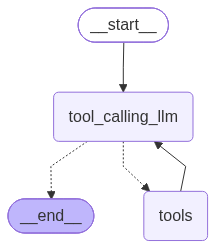

In [27]:
### let's create  state graph 
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node defination
def tool_calling_llm(state):
    return {"messages": [llm_with_tool.invoke(state["messages"])]}
# graph 
builder = StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## add edges
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")
## complie the graph
graph=builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [28]:
## Now this will answer correctly 
responce = graph.invoke({"messages":"give me the recent ai news  and then multiply 5 * 20"})
for m in responce["messages"]:
    m.pretty_print()

================================ Human Message =================================

give me the recent ai news  and then multiply 5 * 20
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_0463f154-98b5-4f4c-b6f8-fcd4f97ed304)
 Call ID: fc_0463f154-98b5-4f4c-b6f8-fcd4f97ed304
  Args:
    query: recent AI news 2026
    search_depth: advanced
    time_range: day
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news 2026", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://adsknews.autodesk.com/en/news/autodesk-ai-design-manufacturing-au-2026", "title": "Autodesk advances AI for design and manufacturing at AU 2026", "content": "Inventor and Vault: Autodesk Assistant now unlocks Inventor’s robust APIs and iLogic foundation to analyze models, modify parameters and components, create model states, and automat

## Adding Memoery in Agentic Graph 

In [29]:
responce = graph.invoke({"messages":"hello my name is vishal"})
for m in responce["messages"]:
    m.pretty_print()

================================ Human Message =================================

hello my name is vishal
================================== Ai Message ==================================

Hello Vishal! How can I help you today?


In [30]:
responce = graph.invoke({"messages":"what is my name ?"})
for m in responce["messages"]:
    m.pretty_print()

================================ Human Message =================================

what is my name ?
================================== Ai Message ==================================

I’m sorry, but I don’t have any information about your name.


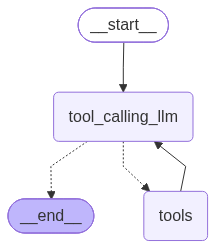

In [31]:
### let's create  state graph 
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

## Node defination
def tool_calling_llm(state):
    return {"messages": [llm_with_tool.invoke(state["messages"])]}
# graph 
builder = StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## add edges
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")
## complie the graph
graph=builder.compile(checkpointer=memory)

display(Image(graph.get_graph().draw_mermaid_png()))

In [32]:
config = {"configurable":{"thread_id":"1"}}
responce = graph.invoke({"messages":"hi my name is vishal "},config=config)
responce

{'messages': [HumanMessage(content='hi my name is vishal ', additional_kwargs={}, response_metadata={}, id='2ff52706-5df5-4373-bb4b-50786565832f'),
  AIMessage(content='Hello Vishal! 👋 How can I help you today?', additional_kwargs={'reasoning_content': 'We need to respond to user greeting. Probably friendly.'}, response_metadata={'token_usage': {'completion_tokens': 34, 'prompt_tokens': 375, 'total_tokens': 409, 'completion_time': 0.034787005, 'completion_tokens_details': {'reasoning_tokens': 12}, 'prompt_time': 0.022634086, 'prompt_tokens_details': None, 'queue_time': 0.050077103, 'total_time': 0.057421091}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_c5a89987dc', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0a681-00e9-77e1-9f41-75b16b3e84d3-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 375, 'output_tokens': 34, 'total_tokens': 409, 'output_token_details': {'reasoning': 1

In [33]:
responce["messages"][-1].content

'Hello Vishal! 👋 How can I help you today?'

In [34]:
responce = graph.invoke({"messages":"what is my name..?"},config=config)
responce



{'messages': [HumanMessage(content='hi my name is vishal ', additional_kwargs={}, response_metadata={}, id='2ff52706-5df5-4373-bb4b-50786565832f'),
  AIMessage(content='Hello Vishal! 👋 How can I help you today?', additional_kwargs={'reasoning_content': 'We need to respond to user greeting. Probably friendly.'}, response_metadata={'token_usage': {'completion_tokens': 34, 'prompt_tokens': 375, 'total_tokens': 409, 'completion_time': 0.034787005, 'completion_tokens_details': {'reasoning_tokens': 12}, 'prompt_time': 0.022634086, 'prompt_tokens_details': None, 'queue_time': 0.050077103, 'total_time': 0.057421091}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_c5a89987dc', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0a681-00e9-77e1-9f41-75b16b3e84d3-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 375, 'output_tokens': 34, 'total_tokens': 409, 'output_token_details': {'reasoning': 1

In [35]:
responce["messages"][-1].content

'Your name is Vishal.'

# Streaming 

In [36]:
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()


In [37]:
def superBot(State: State):
    return {"messages": [llm.invoke(State["messages"])]}

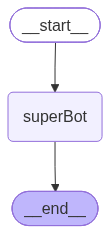

In [38]:
graph= StateGraph(State)

## Node 
graph.add_node("superBot",superBot)

## Edges
graph.add_edge(START,"superBot")
graph.add_edge("superBot",END)

graph_builder = graph.compile(checkpointer=memory)

## Display 
from IPython.display import Image,display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [39]:
config = {"configurable":{"thread_id":"1"}}
responce = graph_builder.invoke({"messages":"hi name is vishal i like poetry"},config)

In [40]:
responce["messages"][-1].content

'Hello, Vishal! 👋 It’s great to meet someone who enjoys poetry.  \n\nDo you have a favorite topic or style you’d like a poem about?  \n- Nature, love, adventure, introspection, or something else?  \n- Short, long, free‑verse, or rhymed?  \n\nLet me know, and I’ll craft something just for you! If you’d like a quick sample right now, here’s a little free‑verse about the quiet moments that make life feel like a poem:\n\n> In the hush between the bustle,  \n>  a single leaf falls—  \n>  its silent arc a whisper of gravity,  \n>  a reminder that even the smallest thing can travel far.  \n\nFeel free to share what resonates, and I’ll write something more tailored.'

## Streaming

**Methods:** `.stream()` and `.astream()`

- These methods are sync and async methods for streaming back results.

### Additional parameters in streaming modes for graph state

- **`values`**: This streams the full state of the graph after each node is called.
- **`updates`**: This streams updates to the state of the graph after each node is called.

In [41]:
config = {"configurable":{"thread_id":"3"}}

for chunk in graph_builder.stream({"messages":"hi my name is vishal i like poetries"},config,stream_mode="updates"):
    print(chunk)

{'superBot': {'messages': [AIMessage(content='Hello Vishal! 👋 It’s great to meet a poetry lover. What kind of poems do you enjoy most—classic sonnets, free‑verse, haikus, or maybe something contemporary? If you’d like, I can share a short poem right now or recommend some poets that match your taste. Let me know!', additional_kwargs={'reasoning_content': 'We need to respond as ChatGPT, presumably friendly. The user says "hi my name is vishal i like poetries". We should respond in a friendly tone, ask about preferences, maybe share a poem or ask what kind of poetry they like. Provide a poem. Also note that the user says "poetries" but that\'s okay. We should keep conversation. Also abide by policies. No issues. We can ask about favorite poet, etc.'}, response_metadata={'token_usage': {'completion_tokens': 170, 'prompt_tokens': 83, 'total_tokens': 253, 'completion_time': 0.190464431, 'completion_tokens_details': {'reasoning_tokens': 95}, 'prompt_time': 0.00408456, 'prompt_tokens_details':

In [42]:
for chunk in graph_builder.stream({"messsages":"hi my name is vishal i like poetries"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='hi my name is vishal i like poetries', additional_kwargs={}, response_metadata={}, id='b6c866de-53c3-44cb-ba52-e0695b409795'), AIMessage(content='Hello Vishal! 👋 It’s great to meet a poetry lover. What kind of poems do you enjoy most—classic sonnets, free‑verse, haikus, or maybe something contemporary? If you’d like, I can share a short poem right now or recommend some poets that match your taste. Let me know!', additional_kwargs={'reasoning_content': 'We need to respond as ChatGPT, presumably friendly. The user says "hi my name is vishal i like poetries". We should respond in a friendly tone, ask about preferences, maybe share a poem or ask what kind of poetry they like. Provide a poem. Also note that the user says "poetries" but that\'s okay. We should keep conversation. Also abide by policies. No issues. We can ask about favorite poet, etc.'}, response_metadata={'token_usage': {'completion_tokens': 170, 'prompt_tokens': 83, 'total_tokens': 253, 'c

In [43]:
config = {"configurable":{"thread_id":"4"}}

for chunk in graph_builder.stream({"messages":"hi my name is vishal i like poetries"},config,stream_mode="updates"):
    print(chunk)

{'superBot': {'messages': [AIMessage(content='Hello, Vishal! It’s great to meet a poetry enthusiast. What kind of poems do you enjoy most—classic sonnets, modern free verse, haikus, or something else? Feel free to share your favorites or let me know if you’d like a poem written for you!', additional_kwargs={'reasoning_content': 'The user says: "hi my name is vishal i like poetries". They want maybe to talk about poetry? The user hasn\'t asked a question. We should respond politely, acknowledging the user and maybe ask about their favorite poems or what they\'d like to do. We should keep the response friendly, maybe ask what type of poetry they like. We need to comply with policies. No issues. Just respond.'}, response_metadata={'token_usage': {'completion_tokens': 152, 'prompt_tokens': 83, 'total_tokens': 235, 'completion_time': 0.170562218, 'completion_tokens_details': {'reasoning_tokens': 85}, 'prompt_time': 0.036255591, 'prompt_tokens_details': None, 'queue_time': 0.222426967, 'tota

In [44]:
for chunk in graph_builder.stream({"messages":"i also like sketching"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='hi my name is vishal i like poetries', additional_kwargs={}, response_metadata={}, id='6566687f-0fb8-4a8c-8cea-53b0e2f83dc5'), AIMessage(content='Hello, Vishal! It’s great to meet a poetry enthusiast. What kind of poems do you enjoy most—classic sonnets, modern free verse, haikus, or something else? Feel free to share your favorites or let me know if you’d like a poem written for you!', additional_kwargs={'reasoning_content': 'The user says: "hi my name is vishal i like poetries". They want maybe to talk about poetry? The user hasn\'t asked a question. We should respond politely, acknowledging the user and maybe ask about their favorite poems or what they\'d like to do. We should keep the response friendly, maybe ask what type of poetry they like. We need to comply with policies. No issues. Just respond.'}, response_metadata={'token_usage': {'completion_tokens': 152, 'prompt_tokens': 83, 'total_tokens': 235, 'completion_time': 0.170562218, 'completio

In [45]:
config = {"configurable":{"thread_id":"5"}}

async for  event in graph_builder.astream_events({"messages":"hi my name is vishal i like poetries"},config,version="v2",):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': 'hi my name is vishal i like poetries'}}, 'name': 'LangGraph', 'tags': [], 'run_id': '01a0a681-185d-7621-a49c-a0f2e6f95514', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='hi my name is vishal i like poetries', additional_kwargs={}, response_metadata={}, id='d15305e2-7840-4b24-b6d3-8f3454efb99e')]}}, 'name': 'superBot', 'tags': ['graph:step:1'], 'run_id': '01a0a681-186e-74b0-918e-7c2f08c6dcfd', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph', 'langgraph_step': 1, 'langgraph_node': 'superBot', 'langgraph_triggers': ('branch:to:superBot',), 'langgraph_path': ('__pregel_pull', 'superBot'), 'langgraph_checkpoint_ns': 'superBot:7c4bf9a2-6ef4-dade-6043-cb23e52e4d54'}, 'parent_ids': ['01a0a681-185d-7621-a49c-a0f2e6f95514']}
{'event': 'on_chat_model_start', 'data': {'input': {'messages': [[HumanMessage(conten

# Human in the loop 

In [46]:
import os 
from langchain.chat_models import init_chat_model
llm = init_chat_model("groq:openai/gpt-oss-20b")
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.1', 'langchain': '1.3.18'}}, profile={'name': 'GPT OSS 20B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000002BCE06B9D10>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000002BCE06B9810>, model_name='openai/gpt-oss-20b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [47]:
from asyncio import graph
from typing import Annotated

from langchain_tavily import TavilySearch
from langchain_core.tools import tool
from typing_extensions import TypedDict

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode,tools_condition

from langgraph.types import Command,interrupt

class State(TypedDict):
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)

@tool
def human_asistance (query:str)->str:
    """request asistance from human"""
    human_responce = interrupt({"query":query})
    return human_responce["data"]

tool = TavilySearch(max_results=2)
tools =[tool,human_asistance]
llm_with_tool = llm.bind_tools(tools)

def chatbot(State:State):
    message =llm_with_tool.invoke(State["messages"])
    # we will be interupting during tool execution 
    # we disable prallel tools calling to avoid  repeating any 
    # tool inovocation when we resume
    return {"messages":[message]}

graph_builder.add_node("chatbot",chatbot)
tool_Node = ToolNode(tools=tools)
graph_builder.add_node("tools",tool_Node)

graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition,
)

graph_builder.add_edge("tools","chatbot")
graph_builder.add_edge(START,"chatbot")


In [48]:
memory=MemorySaver()
graph = graph_builder.compile(checkpointer=memory)

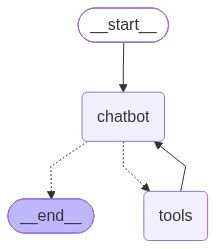

In [49]:
from IPython.display import Image,display


display(Image(graph.get_graph().draw_mermaid_png()))


In [50]:
user_input = "I need some expert guidance for building an AI agent. Could you request assistance for me?"

config = {
    "configurable": {
        "thread_id": "1"
    }
}

events = graph.stream(
    {"messages": [("user", user_input)]},
    config,
    stream_mode="values"
)

for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print() 

================================ Human Message =================================

I need some expert guidance for building an AI agent. Could you request assistance for me?
================================== Ai Message ==================================
Tool Calls:
  human_asistance (fc_ea0181f5-b358-4ef8-8184-56d740fea41a)
 Call ID: fc_ea0181f5-b358-4ef8-8184-56d740fea41a
  Args:
    query: I need some expert guidance for building an AI agent.
================================== Ai Message ==================================
Tool Calls:
  human_asistance (fc_ea0181f5-b358-4ef8-8184-56d740fea41a)
 Call ID: fc_ea0181f5-b358-4ef8-8184-56d740fea41a
  Args:
    query: I need some expert guidance for building an AI agent.


In [51]:
human_response = (
    "We, the experts are here to help! We'd recommend you check out LangGraph to build your agent."
    " It's much more reliable and extensible than simple autonomous agents."
)

human_command = Command(resume={"data": human_response})

events = graph.stream(human_command, config, stream_mode="values")

for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================== Ai Message ==================================
Tool Calls:
  human_asistance (fc_ea0181f5-b358-4ef8-8184-56d740fea41a)
 Call ID: fc_ea0181f5-b358-4ef8-8184-56d740fea41a
  Args:
    query: I need some expert guidance for building an AI agent.
================================= Tool Message =================================
Name: human_asistance

We, the experts are here to help! We'd recommend you check out LangGraph to build your agent. It's much more reliable and extensible than simple autonomous agents.
================================== Ai Message ==================================

Below is a quick‑start playbook for building a production‑ready AI agent.  
It’s written for someone who already has a basic understanding of LLMs but wants a practical roadmap, recommended tooling, and a few “gotchas” to avoid.

---

## 1. Define the Agent’s Purpose

| Step | What to decide | Why it matters |
|------|----------------|----------------|
| **Goal** | What p